In [63]:
# Import Libraries

# Core data manipulation libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Warning control
import warnings

# Scikit-learn utilities
from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Preprocessing tools
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

# Suppress convergence warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.svm import SVR, SVC
from sklearn.neural_network import MLPClassifier

# Evaluation metrics
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)
# Advanced Ensemble Model Comparison
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from xgboost import XGBRegressor, XGBClassifier

import math

In [3]:
#load the dataset
df = pd.read_csv("health_insurance_cost_and_risk_dataset.csv")

In [4]:
# initial data inspection 
print(df.head())
print(df.shape)
print(df.columns)
print(df.info())
print(df.isnull().sum())

    age     sex     bmi  children smoker     region      charges  \
0  19.0  female  27.900       0.0    yes  southwest  16884.92400   
1  18.0    male  33.770       1.0     no  southeast   1725.55230   
2  28.0    male  33.000       3.0     no  southeast   4449.46200   
3  33.0    male  22.705       0.0     no  northwest  21984.47061   
4  32.0    male  28.880       0.0     no  northwest   3866.85520   

   blood_pressure exercise_frequency  pre_existing_condition occupation_risk  \
0           139.0              Never                    True            high   
1           129.9             Weekly                    True        moderate   
2           111.1             Rarely                   False            high   
3           126.9             Rarely                   False            high   
4           134.7             Rarely                    True             low   

   annual_income  
0      104158.67  
1       43530.88  
2      113004.75  
3      185041.26  
4       46747.9

In [5]:
# Remove rows with missing values 
df = df.dropna()

print(df.isnull().sum())
print(df.shape)

age                       0
sex                       0
bmi                       0
children                  0
smoker                    0
region                    0
charges                   0
blood_pressure            0
exercise_frequency        0
pre_existing_condition    0
occupation_risk           0
annual_income             0
dtype: int64
(1335, 12)


In [6]:
# Exploratory Data Analysis (EDA)

# Generate summary statistics for numeric and categorical features 
print(df.describe())
print(df.describe(include='object'))

               age          bmi     children       charges  blood_pressure  \
count  1335.000000  1335.000000  1335.000000   1335.000000     1335.000000   
mean     39.187266    30.665404     1.097378  13255.381012      124.448764   
std      14.034525     6.102598     1.205727  12104.185093        8.552669   
min      18.000000    15.960000     0.000000   1121.873900      110.100000   
25%      27.000000    26.302500     0.000000   4742.306100      117.400000   
50%      39.000000    30.400000     1.000000   9377.904700      124.500000   
75%      51.000000    34.700000     2.000000  16582.138605      131.400000   
max      64.000000    53.130000     5.000000  63770.428010      140.000000   

       annual_income  
count    1335.000000  
mean   114384.827401  
std     49688.080485  
min     30109.230000  
25%     70844.485000  
50%    114372.240000  
75%    157206.265000  
max    199966.140000  
         sex smoker     region exercise_frequency occupation_risk
count   1335   1335     

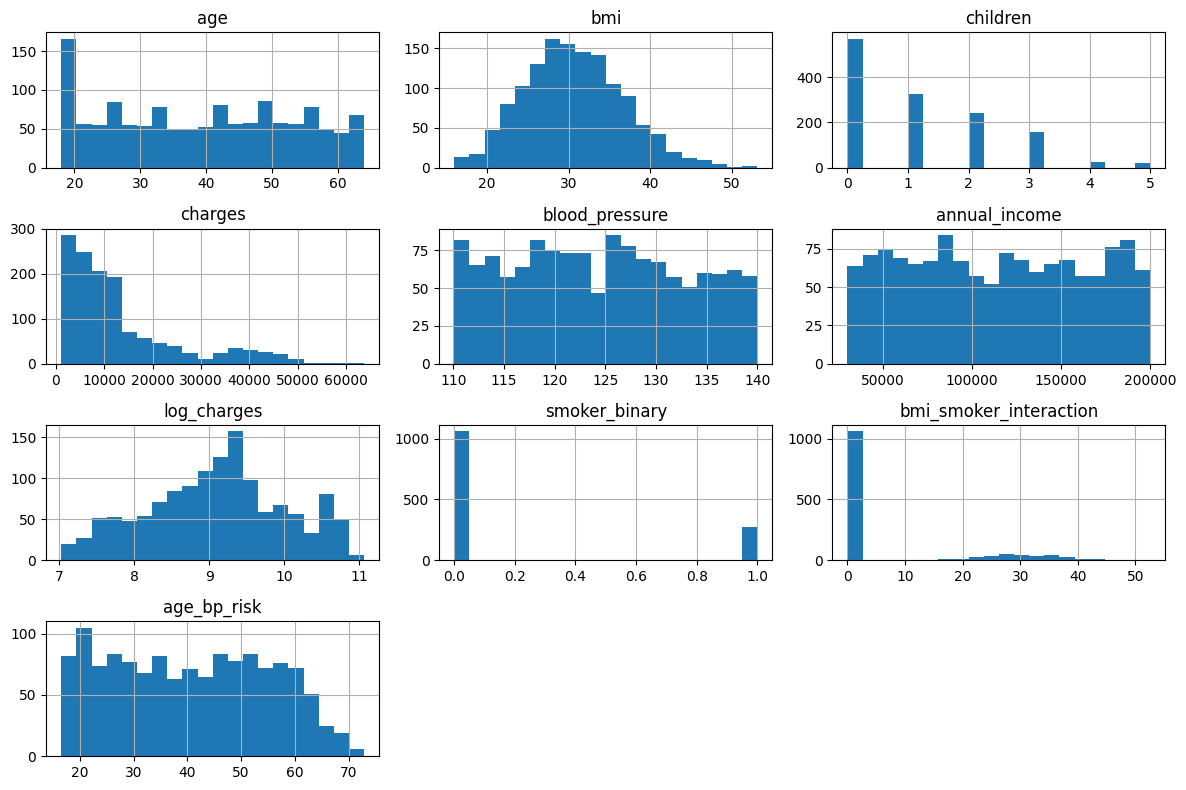

In [65]:
# Plot histograms for all numeric features to visualize their distributions and detect skewness or outliers
df.hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()

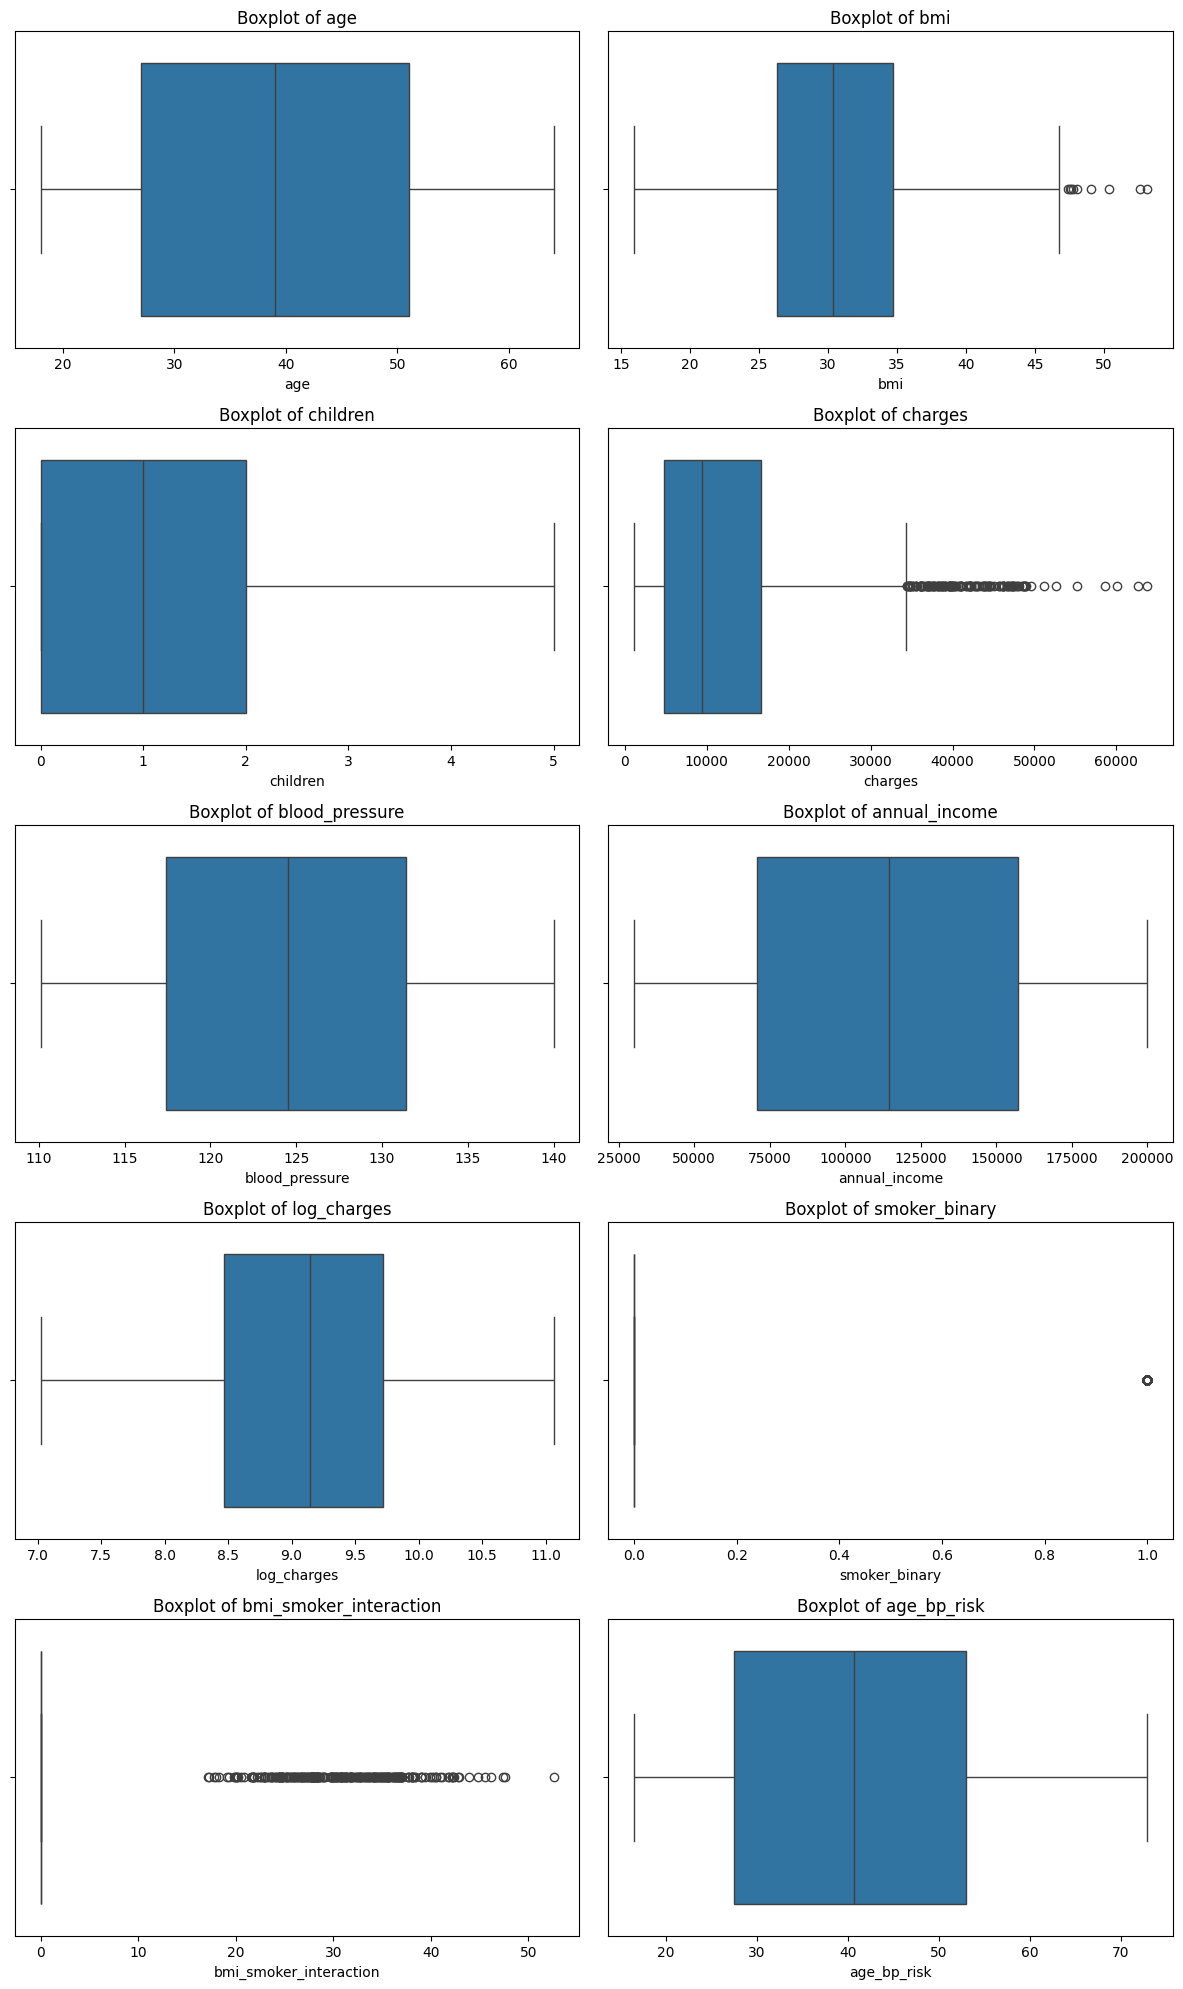

In [64]:
numeric_cols = df.select_dtypes(include=np.number).columns

# Define number of columns per row
n_cols = 2
n_rows = math.ceil(len(numeric_cols) / n_cols)

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()  # Flatten in case of multiple rows

# Loop through columns and plot
for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}")

# Remove empty plots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

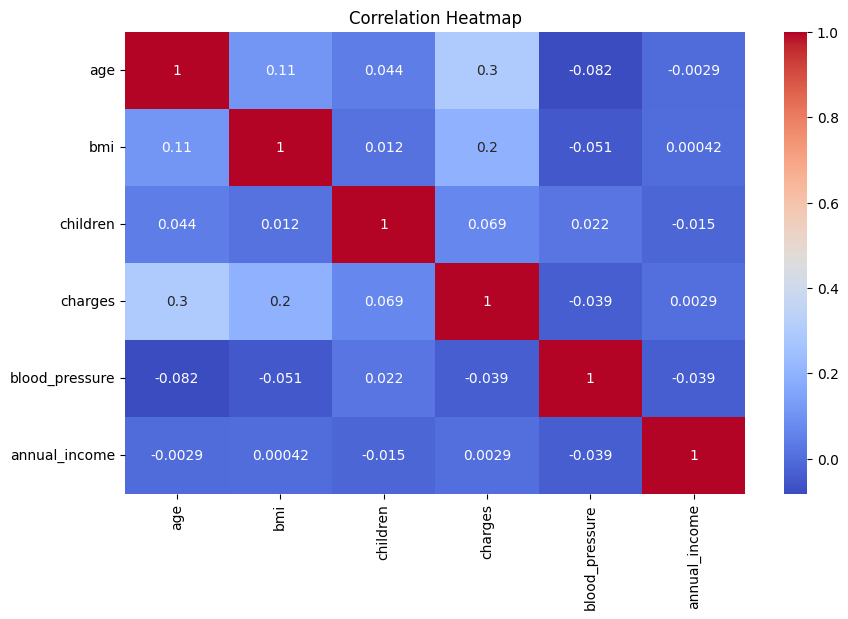

In [10]:
# Plot a correlation heatmap for numeric features to examine relationships between variables
plt.figure(figsize=(10, 6))
sns.heatmap(
    df.select_dtypes(include=np.number).corr(),  # compute correlation matrix for numeric variables
    annot=True,                                  # display correlation values on the heatmap
    cmap="coolwarm"                              # color scheme to highlight positive/negative correlations
)
plt.title("Correlation Heatmap")                 # add title for clarity
plt.show()                                       # display the plot

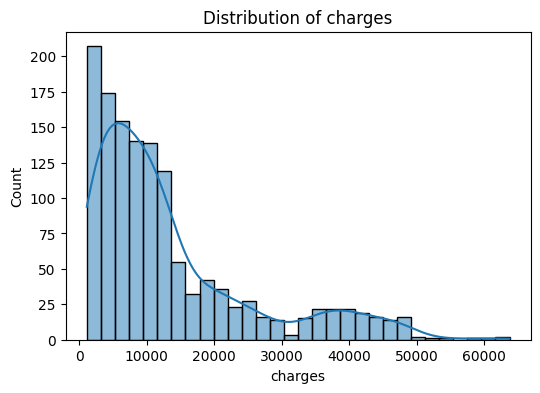

In [11]:
# Visualize the distribution of insurance charges to assess skewness and overall spread
plt.figure(figsize=(6, 4))
sns.histplot(df["charges"], kde=True)   # histogram with KDE to show distribution shape
plt.title("Distribution of charges")
plt.show()

In [12]:
# Apply log transformation to charges to reduce skewness and stabilize variance
df["log_charges"] = np.log1p(df["charges"])

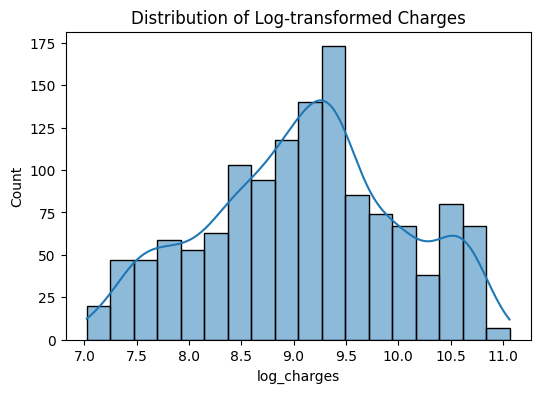

In [13]:
# Visualize the distribution of log-transformed charges to confirm reduced skewness and improved normality
plt.figure(figsize=(6, 4))
sns.histplot(df["log_charges"], kde=True)
plt.title("Distribution of Log-transformed Charges")
plt.show()

In [14]:
# Create risk tiers by dividing charges into three quantile-based categories (Low, Medium, High)
df["risk_tier"] = pd.qcut(df["charges"], q=3, labels=["Low", "Medium", "High"])

# Display the number of observations in each risk category to verify balanced class distribution
print(df["risk_tier"].value_counts())

# Display updated column names to confirm the new feature has been added
print(df.columns)

risk_tier
Low       445
Medium    445
High      445
Name: count, dtype: int64
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges',
       'blood_pressure', 'exercise_frequency', 'pre_existing_condition',
       'occupation_risk', 'annual_income', 'log_charges', 'risk_tier'],
      dtype='object')


In [15]:
# Define feature matrix (X) by removing target variables used for regression and classification
X = df.drop(columns=["charges", "log_charges", "risk_tier"])

In [16]:
# Identify numeric and categorical features for separate preprocessing steps
numeric_features = X.select_dtypes(include=np.number).columns.tolist()       # numeric columns for scaling/imputation
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()   # categorical columns for encoding

# Display identified feature groups for verification
print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

Numeric: ['age', 'bmi', 'children', 'blood_pressure', 'annual_income']
Categorical: ['sex', 'smoker', 'region', 'exercise_frequency', 'pre_existing_condition', 'occupation_risk']


In [18]:
#feature engineering

#convert smoker into numeric form
#yes =1, no =0
df["smoker_binary"] = df["smoker"].map({"yes":1, "no":0})

# create BMI and smoker interaction feature
df["bmi_smoker_interaction"] = df["bmi"] * df["smoker_binary"]

# create age and blood pressure risk feature
df["age_bp_risk"] = df["age"] * df["blood_pressure"] / 120

#check the new columns
print(df[["smoker", "smoker_binary", "bmi", "bmi_smoker_interaction", "age", "blood_pressure", "age_bp_risk"]].head())

  smoker  smoker_binary     bmi  bmi_smoker_interaction   age  blood_pressure  \
0    yes              1  27.900                    27.9  19.0           139.0   
1     no              0  33.770                     0.0  18.0           129.9   
2     no              0  33.000                     0.0  28.0           111.1   
3     no              0  22.705                     0.0  33.0           126.9   
4     no              0  28.880                     0.0  32.0           134.7   

   age_bp_risk  
0    22.008333  
1    19.485000  
2    25.923333  
3    34.897500  
4    35.920000  


In [19]:
# Define feature matrix (X) by removing target variables
X = df.drop(columns=["charges", "log_charges", "risk_tier"], errors="ignore")   # input features

# Define regression target (continuous)
y_reg = df["log_charges"]   # target for regression model

# Define classification target (categorical)
y_clf = df["risk_tier"]     # target for classification model

# Identify numeric and categorical features for preprocessing
numeric_features = X.select_dtypes(include=np.number).columns.tolist()       # numeric features (scaling/imputation)
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()   # categorical features (encoding)

# Print feature groups for verification
print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

Numeric: ['age', 'bmi', 'children', 'blood_pressure', 'annual_income', 'smoker_binary', 'bmi_smoker_interaction', 'age_bp_risk']
Categorical: ['sex', 'smoker', 'region', 'exercise_frequency', 'pre_existing_condition', 'occupation_risk']


In [20]:
# Split data into train, validation, and test sets

# First split: 85% temporary (train+val), 15% test set
X_temp, X_test, y_reg_temp, y_reg_test, y_clf_temp, y_clf_test = train_test_split(
    X, y_reg, y_clf,
    test_size=0.15,          # 15% reserved for final testing
    random_state=42,         # ensures reproducibility
    stratify=y_clf           # maintain class distribution
)

# Second split: from temp (70% train, 15% validation)
X_train, X_val, y_reg_train, y_reg_val, y_clf_train, y_clf_val = train_test_split(
    X_temp, y_reg_temp, y_clf_temp,
    test_size=0.1765,        # proportion chosen to get 70/15/15 split overall
    random_state=42,
    stratify=y_clf_temp     
)

In [21]:
# Preprocessing pipeline for numeric and categorical features

# Numeric pipeline: handle missing values and scale features
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),   # fill missing values with median
    ("scaler", StandardScaler())                     # standardize numeric features
])

# Categorical pipeline: handle missing values and encode categories
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),  # fill missing values with most frequent category
    ("onehot", OneHotEncoder(handle_unknown="ignore"))     # convert categories to numerical format
])

# Combine both pipelines into a single preprocessor
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),        # apply numeric pipeline
    ("cat", categorical_transformer, categorical_features) # apply categorical pipeline
])

In [22]:
# PCA on numeric features to reduce dimensionality and analyze variance

X_num = df[numeric_features].copy()        # select only numeric features

scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)  # scale features 

pca = PCA()
X_pca = pca.fit_transform(X_num_scaled)     # apply PCA transformation

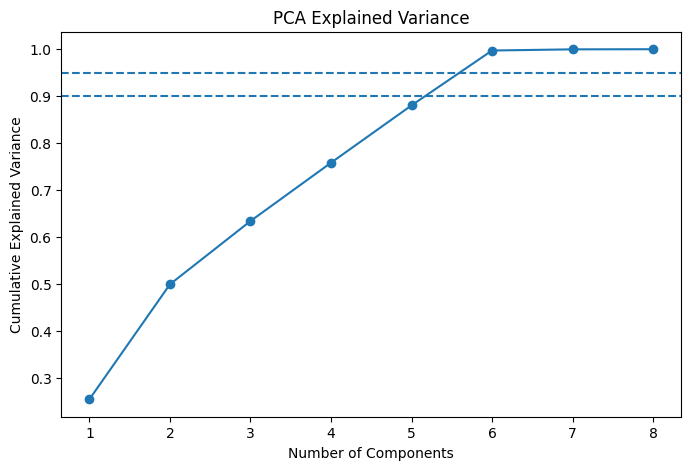

In [23]:
# Plot cumulative variance to determine optimal number of PCA components

explained_var = np.cumsum(pca.explained_variance_ratio_)   # cumulative variance 

plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_var)+1), explained_var, marker='o')  # variance curve

plt.axhline(y=0.90, linestyle='--')   # 90% variance threshold
plt.axhline(y=0.95, linestyle='--')   # 95% variance threshold

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.show()

In [24]:
# Compute PCA loadings to understand contribution of each feature to principal components

loadings = pd.DataFrame(
    pca.components_.T,                                 # transpose to align features with components
    columns=[f"PC{i+1}" for i in range(len(numeric_features))],  # label principal components
    index=numeric_features                             # original feature names
)

print(loadings)   # display feature contributions to each principal component

                             PC1       PC2       PC3       PC4       PC5  \
age                     0.548086  0.430039 -0.051128 -0.074884  0.008369   
bmi                     0.064884  0.163451 -0.390187  0.442646 -0.367202   
children                0.045977  0.053918  0.278444  0.844316  0.415210   
blood_pressure          0.040284 -0.031757  0.732940 -0.187860  0.156212   
annual_income           0.031923 -0.058284 -0.469026 -0.180622  0.811405   
smoker_binary          -0.441675  0.542779  0.049478 -0.073001  0.075236   
bmi_smoker_interaction -0.433941  0.554311  0.003731 -0.031465  0.050296   
age_bp_risk             0.554305  0.423282  0.089222 -0.106549  0.041510   

                             PC6       PC7       PC8  
age                    -0.130346 -0.006298 -0.699533  
bmi                     0.692967 -0.076499 -0.000374  
children               -0.179347  0.001799 -0.003195  
blood_pressure          0.618285 -0.007525 -0.134690  
annual_income           0.290554 -0.0131

In [25]:
# PCA vs Original Feature Comparison

# Apply preprocessing 
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Convert sparse matrix to dense 
X_train_dense = X_train_processed.toarray() if hasattr(X_train_processed, "toarray") else X_train_processed
X_test_dense = X_test_processed.toarray() if hasattr(X_test_processed, "toarray") else X_test_processed

# Apply PCA to retain 95% of variance
pca_model = PCA(n_components=0.95)
X_train_pca = pca_model.fit_transform(X_train_dense)   # reduced feature space
X_test_pca = pca_model.transform(X_test_dense)

# Train SVR on original features
svr_original = SVR(kernel="rbf", C=10, gamma="scale")
svr_original.fit(X_train_dense, y_reg_train)
pred_original = svr_original.predict(X_test_dense)

# Train SVR on PCA-reduced features
svr_pca = SVR(kernel="rbf", C=10, gamma="scale")
svr_pca.fit(X_train_pca, y_reg_train)
pred_pca = svr_pca.predict(X_test_pca)

# Compare performance using R^2 and dimensionality
print("PCA vs Original Comparison:")
print("Original R2:", r2_score(y_reg_test, pred_original))
print("PCA R2:", r2_score(y_reg_test, pred_pca))
print("Original dimensions:", X_train_dense.shape[1])
print("PCA dimensions:", X_train_pca.shape[1])

PCA vs Original Comparison:
Original R2: 0.854952366034254
PCA R2: 0.8411233909332297
Original dimensions: 25
PCA dimensions: 14


In [26]:
# Linear Regression model with preprocessing pipeline

linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),        # apply preprocessing 
    ("model", LinearRegression())          # baseline regression model
])

# Train the model
linear_model.fit(X_train, y_reg_train)

# Make predictions on test set
pred_lr = linear_model.predict(X_test)

# Evaluate model performance using standard regression metrics
print("Linear Regression")
print("MAE:", mean_absolute_error(y_reg_test, pred_lr))                # average absolute error
print("RMSE:", np.sqrt(mean_squared_error(y_reg_test, pred_lr)))       # penalizes large errors
print("R2:", r2_score(y_reg_test, pred_lr))                           

Linear Regression
MAE: 0.22062091436679818
RMSE: 0.35530895745721225
R2: 0.8417830832083997


In [27]:
# Ridge Regression model with L2 regularization to reduce overfitting

ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),   # apply preprocessing 
    ("model", Ridge(alpha=1.0))       # Ridge regression with regularization strength alpha
])

# Train the model
ridge_model.fit(X_train, y_reg_train)

# Make predictions on test set
pred_ridge = ridge_model.predict(X_test)

# Evaluate model performance
print("Ridge")
print("MAE:", mean_absolute_error(y_reg_test, pred_ridge))              # average absolute error
print("RMSE:", np.sqrt(mean_squared_error(y_reg_test, pred_ridge)))     # penalizes large errors
print("R2:", r2_score(y_reg_test, pred_ridge))                          

Ridge
MAE: 0.22048937841614483
RMSE: 0.3551497259610662
R2: 0.8419248610651506


In [28]:
# Lasso Regression model with L1 regularization for feature selection

lasso_model = Pipeline(steps=[
    ("preprocessor", preprocessor),   # apply preprocessing 
    ("model", Lasso(alpha=0.1))       # Lasso regression with regularization strength alpha
])

# Train the model
lasso_model.fit(X_train, y_reg_train)

# Make predictions on test set
pred_lasso = lasso_model.predict(X_test)

# Evaluate model performance
print("Lasso")
print("MAE:", mean_absolute_error(y_reg_test, pred_lasso))              # average absolute error
print("RMSE:", np.sqrt(mean_squared_error(y_reg_test, pred_lasso)))     # penalizes large errors
print("R2:", r2_score(y_reg_test, pred_lasso))                          

Lasso
MAE: 0.24112719082946063
RMSE: 0.3785381298777774
R2: 0.8204192136898325


In [29]:
# Support Vector Regression (SVR) with RBF kernel for capturing non-linear relationships

svr_model = Pipeline(steps=[
    ("preprocessor", preprocessor),            # apply preprocessing
    ("model", SVR(kernel="rbf", C=10, gamma="scale"))   # SVR with radial basis function kernel
])

# Train the model
svr_model.fit(X_train, y_reg_train)

# Make predictions on test set
pred_svr = svr_model.predict(X_test)

# Evaluate model performance
print("SVR")
print("MAE:", mean_absolute_error(y_reg_test, pred_svr))              # average absolute error
print("RMSE:", np.sqrt(mean_squared_error(y_reg_test, pred_svr)))     # penalizes large errors
print("R2:", r2_score(y_reg_test, pred_svr))                          

SVR
MAE: 0.21629629970249367
RMSE: 0.340200558516024
R2: 0.854952366034254


In [30]:
# Cross-validation for regression models to evaluate stability and generalization performance
from sklearn.model_selection import cross_val_score

cv_results = []   # store mean and std of CV scores for each model

# Loop through each regression model
for name, model in [
    ("Linear", linear_model),
    ("Ridge", ridge_model),
    ("Lasso", lasso_model),
    ("SVR", svr_model)
]:
# Perform 5-fold cross-validation using R^2 as evaluation metric
    scores = cross_val_score(model, X_train, y_reg_train, cv=5, scoring="r2")
    
# Store model name, mean score, and standard deviation
    cv_results.append([name, scores.mean(), scores.std()])

# Create DataFrame for comparison
cv_results_df = pd.DataFrame(cv_results, columns=["Model", "Mean CV R2", "Std CV R2"])

# Display results
print("Cross Validation Results:")
print(cv_results_df)

Cross Validation Results:
    Model  Mean CV R2  Std CV R2
0  Linear    0.770138   0.023727
1   Ridge    0.770289   0.023545
2   Lasso    0.733609   0.025972
3     SVR    0.762529   0.019531


In [31]:
# Encode classification target labels into numeric format

label_encoder = LabelEncoder()   # initialize label encoder

# Fit encoder on training labels and transform them
y_clf_train_enc = label_encoder.fit_transform(y_clf_train)   # training labels

# Transform validation and test labels using same encoder
y_clf_val_enc = label_encoder.transform(y_clf_val)           # validation labels
y_clf_test_enc = label_encoder.transform(y_clf_test)         # test labels

In [32]:
# Logistic Regression classifier with preprocessing pipeline

log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),           # apply preprocessing 
    ("model", LogisticRegression(max_iter=2000))   # logistic regression classifier
])

# Train the model
log_model.fit(X_train, y_clf_train_enc)

# Make predictions on test set
pred_log = log_model.predict(X_test)

# Evaluate classification performance
print("Logistic Regression")
print("Accuracy:", accuracy_score(y_clf_test_enc, pred_log))                 # overall prediction accuracy
print("F1:", f1_score(y_clf_test_enc, pred_log, average="macro"))            # balanced performance across classes

# Detailed classification report (precision, recall, F1 per class)
print(classification_report(
    y_clf_test_enc, pred_log,
    target_names=label_encoder.classes_     # original class labels
))

Logistic Regression
Accuracy: 0.835820895522388
F1: 0.8354189669979144
              precision    recall  f1-score   support

        High       0.96      0.67      0.79        67
         Low       0.92      0.90      0.91        67
      Medium       0.71      0.94      0.81        67

    accuracy                           0.84       201
   macro avg       0.86      0.84      0.84       201
weighted avg       0.86      0.84      0.84       201



In [33]:
# SVM classifier with RBF kernel for non-linear classification

svc_model = Pipeline(steps=[
    ("preprocessor", preprocessor),                 # apply preprocessing
    ("model", SVC(kernel="rbf", C=10, gamma="scale", probability=True))  # SVM with RBF kernel and probability estimates
])

# Train the model
svc_model.fit(X_train, y_clf_train_enc)

# Make predictions on test set
pred_svc = svc_model.predict(X_test)

# Evaluate classification performance
print("SVM Classifier")
print("Accuracy:", accuracy_score(y_clf_test_enc, pred_svc))              # overall prediction accuracy
print("F1:", f1_score(y_clf_test_enc, pred_svc, average="macro"))         # balanced performance across classes

# Detailed classification report (precision, recall, F1 per class)
print(classification_report(
    y_clf_test_enc, pred_svc,
    target_names=label_encoder.classes_ 
))

SVM Classifier
Accuracy: 0.8706467661691543
F1: 0.8708728955745504
              precision    recall  f1-score   support

        High       0.89      0.82      0.85        67
         Low       0.93      0.93      0.93        67
      Medium       0.81      0.87      0.83        67

    accuracy                           0.87       201
   macro avg       0.87      0.87      0.87       201
weighted avg       0.87      0.87      0.87       201



In [34]:
# Neural Network (MLP) classifier with hidden layers for capturing complex patterns

from sklearn.neural_network import MLPClassifier

mlp_model = Pipeline(steps=[
    ("preprocessor", preprocessor),   # apply preprocessing
    ("model", MLPClassifier(
        hidden_layer_sizes=(64, 32),  # two hidden layers with 64 and 32 neurons
        activation="relu",            # non-linear activation function
        solver="adam",                # optimization algorithm
        alpha=0.001,                  # L2 regularization strength
        max_iter=500,                 # maximum training iterations
        early_stopping=True,          # stop training when validation performance stops improving
        validation_fraction=0.1,      # portion of training data used for validation
        random_state=42
    ))
])

# Train the model
mlp_model.fit(X_train, y_clf_train_enc)

# Make predictions on test set
pred_mlp = mlp_model.predict(X_test)

# Evaluate classification performance
print("MLP Neural Network")
print("Accuracy:", accuracy_score(y_clf_test_enc, pred_mlp))         # overall prediction accuracy
print("F1:", f1_score(y_clf_test_enc, pred_mlp, average="macro"))    # balanced performance across classes

MLP Neural Network
Accuracy: 0.845771144278607
F1: 0.844844003426093


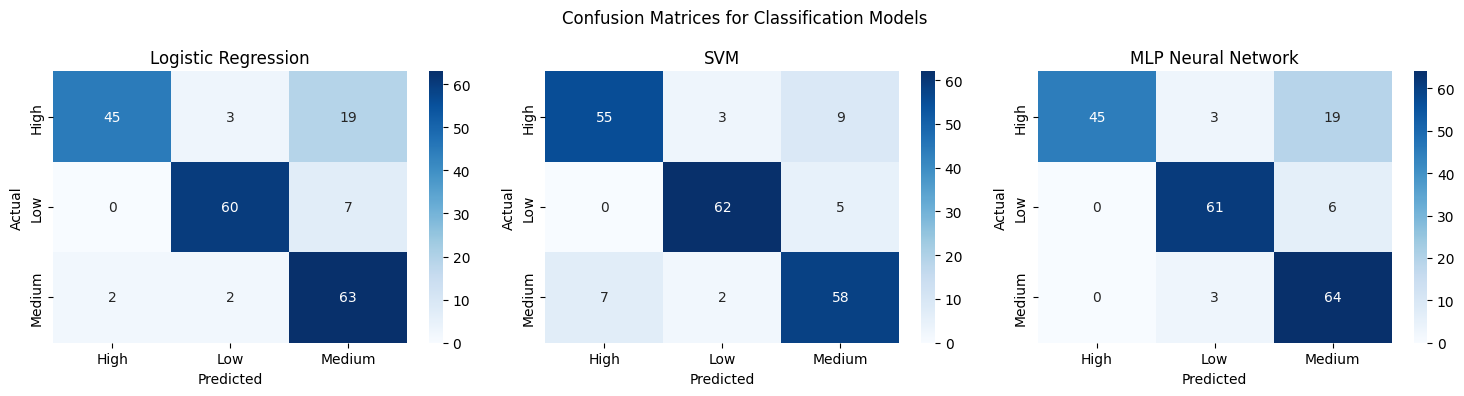

In [36]:
# Confusion matrices to evaluate classification performance across models

fig, axes = plt.subplots(1, 3, figsize=(15, 4))   # create subplots for each model

# Model names and predictions
models = [
    ("Logistic Regression", pred_log),
    ("SVM", pred_svc),
    ("MLP Neural Network", pred_mlp)
]

# Plot confusion matrix for each model
for ax, (name, preds) in zip(axes, models):
    cm = confusion_matrix(y_clf_test_enc, preds)   # compute confusion matrix

    sns.heatmap(
        cm,
        annot=True,                # show counts
        fmt="d",                   # integer format
        cmap="Blues",
        ax=ax,
        xticklabels=label_encoder.classes_,  # predicted labels
        yticklabels=label_encoder.classes_   # actual labels
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices for Classification Models")  # overall title
plt.tight_layout()
plt.show()

In [37]:
# Compute AUC-ROC scores to evaluate model ability to distinguish between classes

# Get predicted probabilities for each model
log_probs = log_model.predict_proba(X_test)   # Logistic Regression probabilities
svc_probs = svc_model.predict_proba(X_test)   # SVM probabilities (requires probability=True)
mlp_probs = mlp_model.predict_proba(X_test)   # MLP probabilities

# Calculate and display AUC-ROC scores (one-vs-rest for multiclass)
print("AUC-ROC Scores:")
print("Logistic:", roc_auc_score(y_clf_test_enc, log_probs, multi_class="ovr"))
print("SVM:", roc_auc_score(y_clf_test_enc, svc_probs, multi_class="ovr"))
print("MLP:", roc_auc_score(y_clf_test_enc, mlp_probs, multi_class="ovr"))

AUC-ROC Scores:
Logistic: 0.9397044627608228
SVM: 0.9560406920620776
MLP: 0.9427489418578748


╒═════════╤════════╤════════╤════════╕
│ Model   │    MAE │   RMSE │     R2 │
╞═════════╪════════╪════════╪════════╡
│ Linear  │ 0.2206 │ 0.3553 │ 0.8418 │
├─────────┼────────┼────────┼────────┤
│ Ridge   │ 0.2205 │ 0.3551 │ 0.8419 │
├─────────┼────────┼────────┼────────┤
│ Lasso   │ 0.2411 │ 0.3785 │ 0.8204 │
├─────────┼────────┼────────┼────────┤
│ SVR     │ 0.2163 │ 0.3402 │ 0.855  │
╘═════════╧════════╧════════╧════════╛


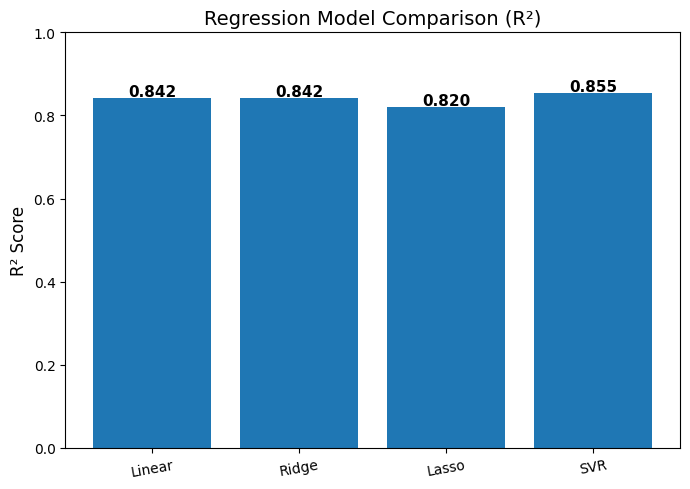

In [70]:
# Regression model comparison table to summarize performance across models

# Create regression results table
reg_results = pd.DataFrame({
    "Model": ["Linear", "Ridge", "Lasso", "SVR"],

    # Mean Absolute Error
    "MAE": [
        mean_absolute_error(y_reg_test, pred_lr),
        mean_absolute_error(y_reg_test, pred_ridge),
        mean_absolute_error(y_reg_test, pred_lasso),
        mean_absolute_error(y_reg_test, pred_svr)
    ],

    # Root Mean Squared Error
    "RMSE": [
        np.sqrt(mean_squared_error(y_reg_test, pred_lr)),
        np.sqrt(mean_squared_error(y_reg_test, pred_ridge)),
        np.sqrt(mean_squared_error(y_reg_test, pred_lasso)),
        np.sqrt(mean_squared_error(y_reg_test, pred_svr))
    ],

    # R² Score
    "R2": [
        r2_score(y_reg_test, pred_lr),
        r2_score(y_reg_test, pred_ridge),
        r2_score(y_reg_test, pred_lasso),
        r2_score(y_reg_test, pred_svr)
    ]
})

# Display clean formatted table
print(
    tabulate(
        reg_results.round(4),
        headers="keys",
        tablefmt="fancy_grid",
        showindex=False
    )
)
# Regression Model Comparison (R²)

plt.figure(figsize=(7,5))

# Create bar chart
bars = plt.bar(
    reg_results["Model"],
    reg_results["R2"]
)

# Add R² values on top of bars
for bar in bars:
    height = bar.get_height()
    
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.005,
        f"{height:.3f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

# Labels and title
plt.title("Regression Model Comparison (R²)", fontsize=14)
plt.ylabel("R² Score", fontsize=12)

# Set y-axis range
plt.ylim(0, 1.0)

# Rotate x labels slightly
plt.xticks(rotation=10)

# Clean layout
plt.tight_layout()

plt.show()

╒═════════════════════╤════════════╤════════════╤═══════════╕
│ Model               │   Accuracy │   Macro F1 │   AUC-ROC │
╞═════════════════════╪════════════╪════════════╪═══════════╡
│ Logistic Regression │     0.8358 │     0.8354 │    0.9397 │
├─────────────────────┼────────────┼────────────┼───────────┤
│ SVM                 │     0.8706 │     0.8709 │    0.956  │
├─────────────────────┼────────────┼────────────┼───────────┤
│ MLP Neural Network  │     0.8458 │     0.8448 │    0.9427 │
╘═════════════════════╧════════════╧════════════╧═══════════╛


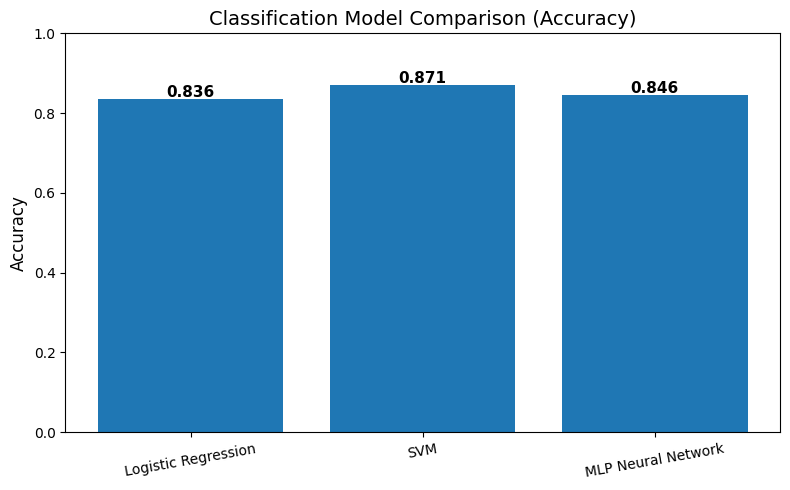

In [73]:
# Classification
# Classification Model Comparison (Accuracy)

# Display clean formatted table
print(
    tabulate(
        clf_results.round(4),
        headers="keys",
        tablefmt="fancy_grid",
        showindex=False
    )
)

# Classification Accuracy Bar Chart
plt.figure(figsize=(8,5))

# Create bar chart
bars = plt.bar(
    clf_results["Model"],
    clf_results["Accuracy"]
)

# Add accuracy values on top of bars
for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.005,
        f"{height:.3f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

# Labels and title
plt.title("Classification Model Comparison (Accuracy)", fontsize=14)
plt.ylabel("Accuracy", fontsize=12)

plt.ylim(0, 1.0)

# Rotate labels slightly
plt.xticks(rotation=10)

# Clean layout
plt.tight_layout()

plt.show()

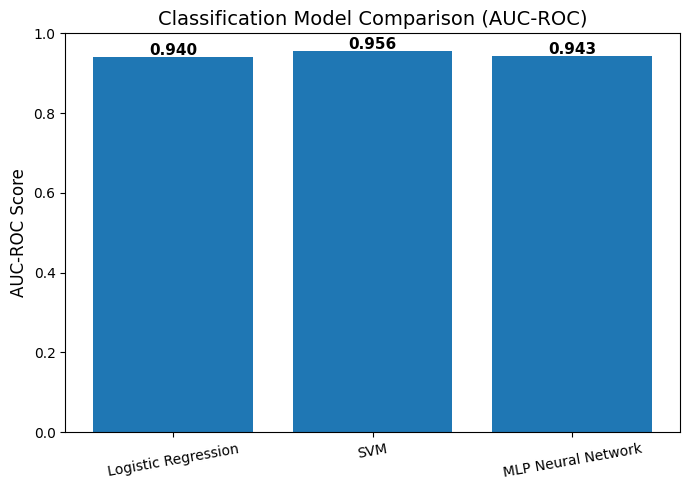

In [74]:
# AUC-ROC Comparison Bar Chart

plt.figure(figsize=(7,5))

# Create bar chart
bars = plt.bar(
    clf_results["Model"],
    clf_results["AUC-ROC"]
)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.005,
        f"{height:.3f}",
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

# Labels and title
plt.title("Classification Model Comparison (AUC-ROC)", fontsize=14)
plt.ylabel("AUC-ROC Score", fontsize=12)

# Set y-axis range
plt.ylim(0, 1.0)

# Rotate labels slightly
plt.xticks(rotation=10)

# Clean layout
plt.tight_layout()

plt.show()

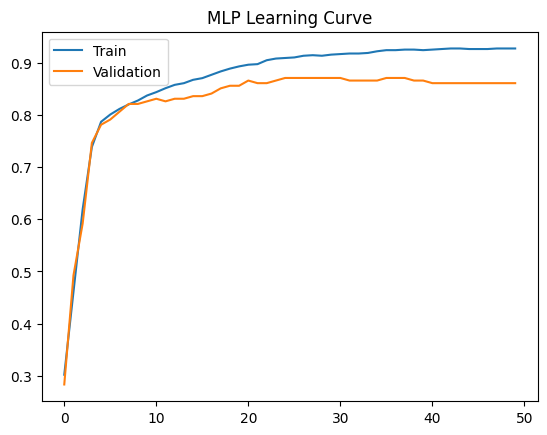

In [76]:
# MLP learning curve to visualize training vs validation performance over iterations

mlp_only = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    max_iter=1,            # train one iteration at a time
    warm_start=True,       # retain model state across iterations
    random_state=42
)

# Apply preprocessing
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc = preprocessor.transform(X_val)

train_acc = []   # store training accuracy
val_acc = []     # store validation accuracy

# Train model iteratively to track learning progress
for i in range(50):
    mlp_only.fit(X_train_proc, y_clf_train_enc)

    train_pred = mlp_only.predict(X_train_proc)
    val_pred = mlp_only.predict(X_val_proc)

    train_acc.append(accuracy_score(y_clf_train_enc, train_pred))   # training accuracy
    val_acc.append(accuracy_score(y_clf_val_enc, val_pred))         # validation accuracy

# Plot learning curves
plt.plot(train_acc, label="Train")
plt.plot(val_acc, label="Validation")
plt.legend()
plt.title("MLP Learning Curve")
plt.show()

╒═══════════════╤════════════╤════════════╤═══════════╕
│ Model         │   Accuracy │   Macro F1 │   AUC-ROC │
╞═══════════════╪════════════╪════════════╪═══════════╡
│ Random Forest │     0.9204 │     0.9202 │    0.965  │
├───────────────┼────────────┼────────────┼───────────┤
│ XGBoost       │     0.9204 │     0.9198 │    0.9635 │
╘═══════════════╧════════════╧════════════╧═══════════╛


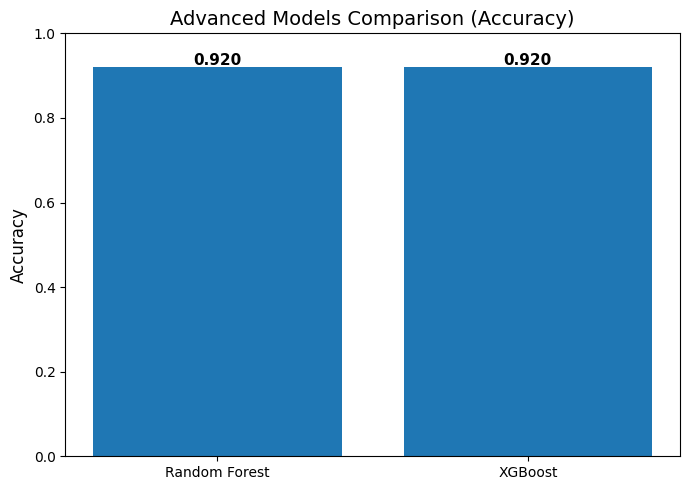

In [71]:
# Advanced Model Extension: Classification using ensemble models (Random Forest vs XGBoost)

# Random Forest Classifier
rf_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),   # preprocessing
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

# XGBoost Classifier
xgb_clf = Pipeline(steps=[
    ("preprocessor", preprocessor),   # preprocessing
    ("model", XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42,
        eval_metric="mlogloss"
    ))
])

# Train models
rf_clf.fit(X_train, y_clf_train_enc)
xgb_clf.fit(X_train, y_clf_train_enc)

# Generate predictions
pred_rf_clf = rf_clf.predict(X_test)
pred_xgb_clf = xgb_clf.predict(X_test)

# Generate predicted probabilities for AUC-ROC
rf_probs = rf_clf.predict_proba(X_test)
xgb_probs = xgb_clf.predict_proba(X_test)

# Create comparison table
advanced_clf_results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],

    "Accuracy": [
        accuracy_score(y_clf_test_enc, pred_rf_clf),
        accuracy_score(y_clf_test_enc, pred_xgb_clf)
    ],

    "Macro F1": [
        f1_score(y_clf_test_enc, pred_rf_clf, average="macro"),
        f1_score(y_clf_test_enc, pred_xgb_clf, average="macro")
    ],

    "AUC-ROC": [
        roc_auc_score(y_clf_test_enc, rf_probs, multi_class="ovr"),
        roc_auc_score(y_clf_test_enc, xgb_probs, multi_class="ovr")
    ]
})

# Display table
print(
    tabulate(
        advanced_clf_results.round(4),
        headers="keys",
        tablefmt="fancy_grid",
        showindex=False
    )
)

# Plot Accuracy comparison
plt.figure(figsize=(7, 5))

bars = plt.bar(
    advanced_clf_results["Model"],
    advanced_clf_results["Accuracy"]
)

# Add accuracy values on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.005,
        f"{height:.3f}",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.title("Advanced Models Comparison (Accuracy)", fontsize=14)
plt.ylabel("Accuracy", fontsize=12)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

╒═══════════════╤════════╤════════╤════════╕
│ Model         │    MAE │   RMSE │     R2 │
╞═══════════════╪════════╪════════╪════════╡
│ Random Forest │ 0.1645 │ 0.3033 │ 0.8847 │
├───────────────┼────────┼────────┼────────┤
│ XGBoost       │ 0.1586 │ 0.2971 │ 0.8894 │
╘═══════════════╧════════╧════════╧════════╛


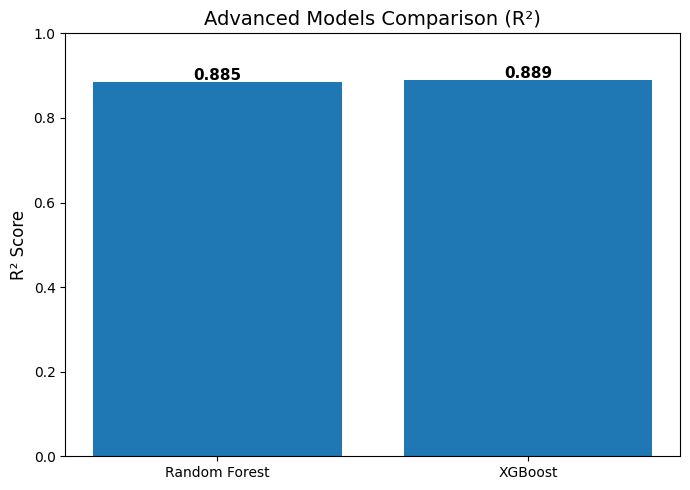

In [75]:
# Advanced Regression Models Comparison (R²)

from tabulate import tabulate

# Display table
print(
    tabulate(
        advanced_reg_results.round(4),
        headers="keys",
        tablefmt="fancy_grid",
        showindex=False
    )
)

# Create bar chart
plt.figure(figsize=(7,5))

bars = plt.bar(
    advanced_reg_results["Model"],
    advanced_reg_results["R2"]
)

# Add R² values on top
for bar in bars:
    height = bar.get_height()
    
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.005,
        f"{height:.3f}",
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

# Labels and title
plt.title("Advanced Models Comparison (R²)", fontsize=14)
plt.ylabel("R² Score", fontsize=12)
plt.ylim(0, 1)

# Clean layout
plt.tight_layout()

plt.show()

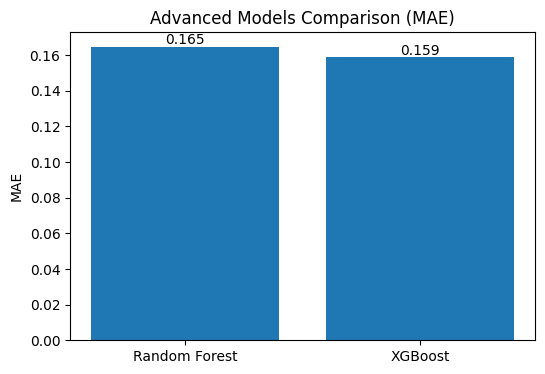

In [77]:
plt.figure(figsize=(6,4))

bars = plt.bar(advanced_reg_results["Model"], advanced_reg_results["MAE"])

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f"{height:.3f}",
             ha='center', va='bottom')

plt.title("Advanced Models Comparison (MAE)")
plt.ylabel("MAE")
plt.show()

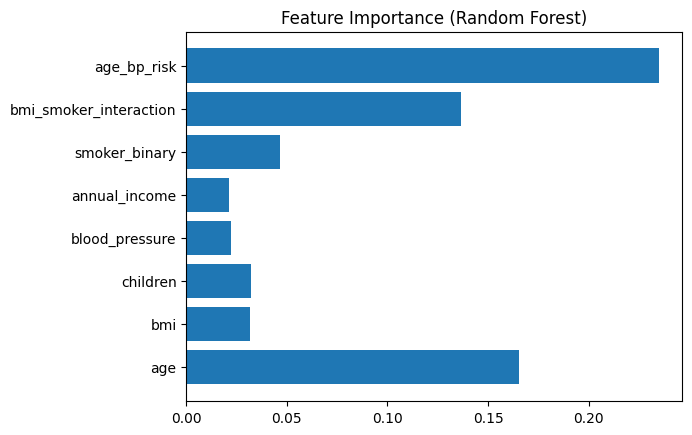

In [44]:
rf = rf_reg.named_steps["model"]
importances = rf.feature_importances_

plt.barh(numeric_features, importances[:len(numeric_features)])
plt.title("Feature Importance (Random Forest)")
plt.show()

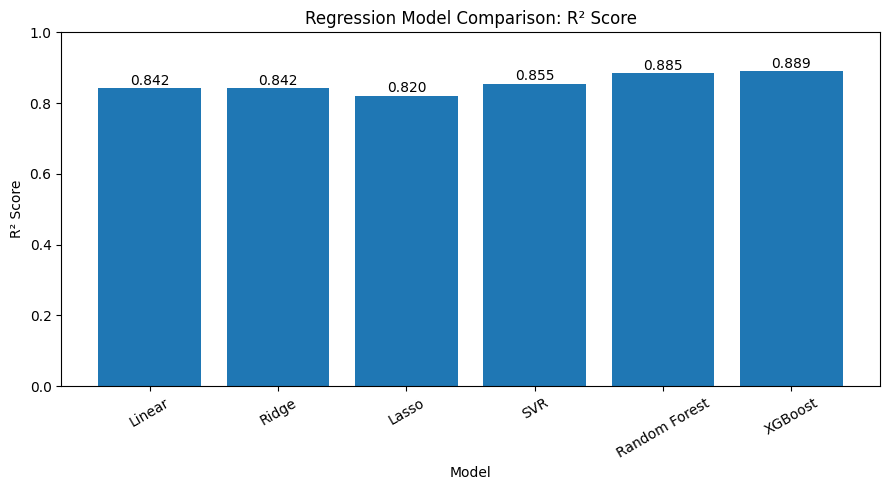

In [46]:
# Combined regression model comparison chart

combined_reg_results = pd.concat(
    [reg_results, advanced_reg_results],
    ignore_index=True
)

plt.figure(figsize=(9, 5))

bars = plt.bar(
    combined_reg_results["Model"],
    combined_reg_results["R2"]
)

plt.title("Regression Model Comparison: R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.ylim(0, 1)
plt.xticks(rotation=30)


# Add value labels above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{height:.3f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

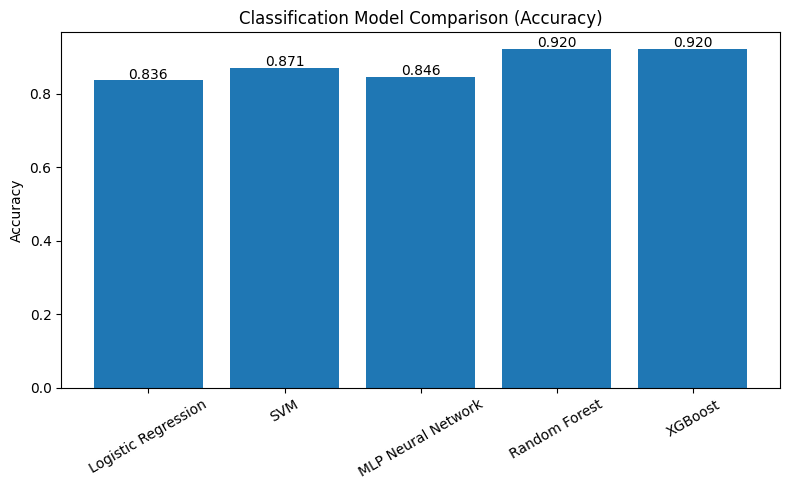

In [47]:
# Combine classification results (including advanced models)
combined_clf_results = pd.concat(
    [clf_results[["Model", "Accuracy"]], advanced_clf_results],
    ignore_index=True
)

plt.figure(figsize=(8,5))

bars = plt.bar(
    combined_clf_results["Model"],
    combined_clf_results["Accuracy"]
)

plt.title("Classification Model Comparison (Accuracy)")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)

# Add labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.005,
        f"{height:.3f}",
        ha="center"
    )

plt.tight_layout()
plt.show()